In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:

import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost.callback import EarlyStopping
import warnings
import time
warnings.filterwarnings('ignore')



# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  semana              625800 non-null  int64         
 12  lag_ventas_1        625800 non-null  fl

# XGBoost

El algoritmo **XGBoost** (eXtreme Gradient Boosting) es una implementación altamente popular, escalable y eficiente de los **Gradient Boosting Decision Trees (GBDT)**. Es un método de **aprendizaje de conjunto (*ensemble*)** que utiliza la estrategia de **Boosting** para construir modelos predictivos robustos.

A continuación, se resume su funcionamiento:

1.  **Mecanismo de Conjunto (Boosting Secuencial):**
    *   **Aprendizaje Aditivo:** XGBoost entrena secuencialmente una serie de árboles de decisión. Cada nuevo árbol busca **corregir los errores** de la suma acumulada de los árboles previamente construidos.
    *   **Optimización:** El proceso está dirigido por la **minimización del gradiente** de la función de pérdida. La predicción final es la suma ponderada de las predicciones de todos los árboles.

2.  **Innovaciones en Eficiencia y Escalabilidad:**
    *   XGBoost se destaca por su **velocidad**, siendo reportado como hasta 10 veces más rápido que otras soluciones de *gradient boosting*. Es ampliamente utilizado para manejar **grandes conjuntos de datos (big data)**.

3.  **Robustez y Control de Modelo:**
    *   **Regularización Explícita:** Para controlar la complejidad del modelo y prevenir el *overfitting* (un riesgo inherente al *boosting*), XGBoost implementa explícitamente términos de **regularización L1 (Lasso) y L2 (Ridge)** directamente en la función objetivo.
    *   **Manejo de Datos Faltantes/Dispersos:** Incorpora un algoritmo de división **"sparsity-aware"** que maneja eficientemente los valores faltantes o dispersos al asignarles una dirección de división predeterminada.
    *   **Grandes Datos en Memoria:** Para conjuntos de datos que no caben completamente en la memoria, utiliza una **aproximación del algoritmo *exact greedy*** para proponer candidatos de división, reduciendo así la memoria y el acceso a disco necesarios.

XGBoost es una herramienta poderosa y versátil para tareas de clasificación y regresión, capaz de modelar **relaciones complejas y no lineales** en los datos, lo que lo hace muy competitivo en el pronóstico de series temporales (siempre y cuando los datos temporales se reformulen con *lag features* y estadísticas *rolling*).



# Preparación de datos

In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE XGBOOST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE XGBOOST


# XGBoost global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: XGBOOST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



🔍 MODELO 1: XGBOOST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔎 Búsqueda de hiperparámetros con Optuna...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA XGBOOST
# =====================================================

def objective_xgb(trial):
    # Hiperparámetros
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3.0),
        # Añadir eval_metric y early_stopping_rounds al constructor
        "eval_metric": "rmse",
        "early_stopping_rounds": 50
    }

    # Crear el modelo
    model = xgb.XGBRegressor(**params)

    # Entrenar con early stopping
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Predicciones y cálculo de MSE
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para XGBoost...")
start_time = time.perf_counter()

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=5, n_jobs=1) 

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros XGBOOST:")
print(study_xgb.best_params)


[I 2025-12-01 22:02:15,595] A new study created in memory with name: no-name-15543c46-925e-4b26-bcbd-7a39e19ee837



🔎 Búsqueda de hiperparámetros con Optuna...

🔍 Iniciando optimización de hiperparámetros con Optuna para XGBoost...


[I 2025-12-01 22:02:47,147] Trial 0 finished with value: 3.865997552871704 and parameters: {'n_estimators': 805, 'learning_rate': 0.0145388074964889, 'max_depth': 12, 'min_child_weight': 5, 'subsample': 0.8391470158261866, 'colsample_bytree': 0.9012126386301076, 'gamma': 1.9207476275263695, 'reg_lambda': 2.4082856730307123}. Best is trial 0 with value: 3.865997552871704.
[I 2025-12-01 22:02:59,640] Trial 1 finished with value: 3.909684419631958 and parameters: {'n_estimators': 326, 'learning_rate': 0.01819230795230333, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.8308350082922377, 'colsample_bytree': 0.8791030359069896, 'gamma': 0.5786289743004012, 'reg_lambda': 1.5087467612190673}. Best is trial 0 with value: 3.865997552871704.
[I 2025-12-01 22:02:59,640] Trial 1 finished with value: 3.909684419631958 and parameters: {'n_estimators': 326, 'learning_rate': 0.01819230795230333, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.8308350082922377, 'colsample_bytree': 0.8791030

✅ Optuna completado en 101.68 segundos

🏆 Mejores hiperparámetros XGBOOST:
{'n_estimators': 805, 'learning_rate': 0.0145388074964889, 'max_depth': 12, 'min_child_weight': 5, 'subsample': 0.8391470158261866, 'colsample_bytree': 0.9012126386301076, 'gamma': 1.9207476275263695, 'reg_lambda': 2.4082856730307123}


In [9]:

best_xgb = xgb.XGBRegressor(
    **study_xgb.best_params,
    random_state=42,
    n_jobs=-1)

best_xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9012126386301076
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_xgb.predict(X_test)

# Calcular métricas (Global)
metricas_test_global = calcular_metricas(
    y_test, y_test_pred,
    algoritmo='XGBoost', ndetalle='Global', cluster=None, producto=None)

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='XGBoost', ndetalle='Global', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='XGBoost',
            ndetalle='Global', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)    



📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost   Global    None     None 1.5692 2.3936 0.2523     49.56     144.53 0.7336     96.1

🏆 Mejor modelo: XGBoost (RMSE: 2.3936)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost   Global      3.0     314.0 0.1564  0.1776  0.0000       NaN     200.00    NaN      NaN
  XGBoost   Global      3.0     257.0 0.7960  1.1642 -0.0214     80.68     188.36 0.7921   159.19
  XGBoost   Global      3.0       NaN 1.0762  1.6694  0.0662     55.10     168.89 0.7491   132.51
  XGBoost   Global      0.0     413.0 1.7650  2.2209 -0.0190     34.31     102.74 0.7775    84.98
  XGBoost   Global      NaN       NaN 1.5692  2.3936  0.2523     49.56     144.53 0.7336    96.10
  XGBoost   Global      0.0       NaN 1.8000  2.5836  0.0932     39.83     125.83 0.7427    93.22
  XGBoost

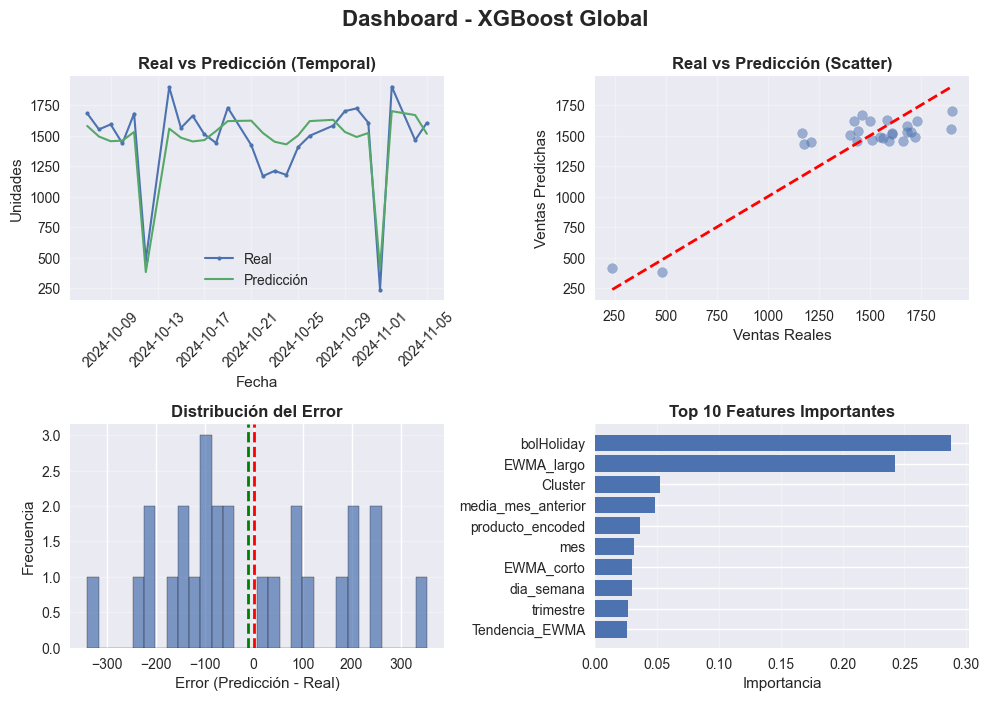

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_xgb,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - XGBoost Global',
        figsize=(10, 7)
        )


# XGBoost por Cluster


🔍 MODELO 2: XGBOOST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        0     None 1.8058 2.5897 0.0889     40.03     125.96 0.7445    93.52

🏆 Mejor modelo: XGBoost (RMSE: 2.5897)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        0     None 1.8058 2.5897 0.0889     40.03     125.96 0.7445    93.52

🏆 Mejor modelo: XGBoost (RMSE: 2.5897)


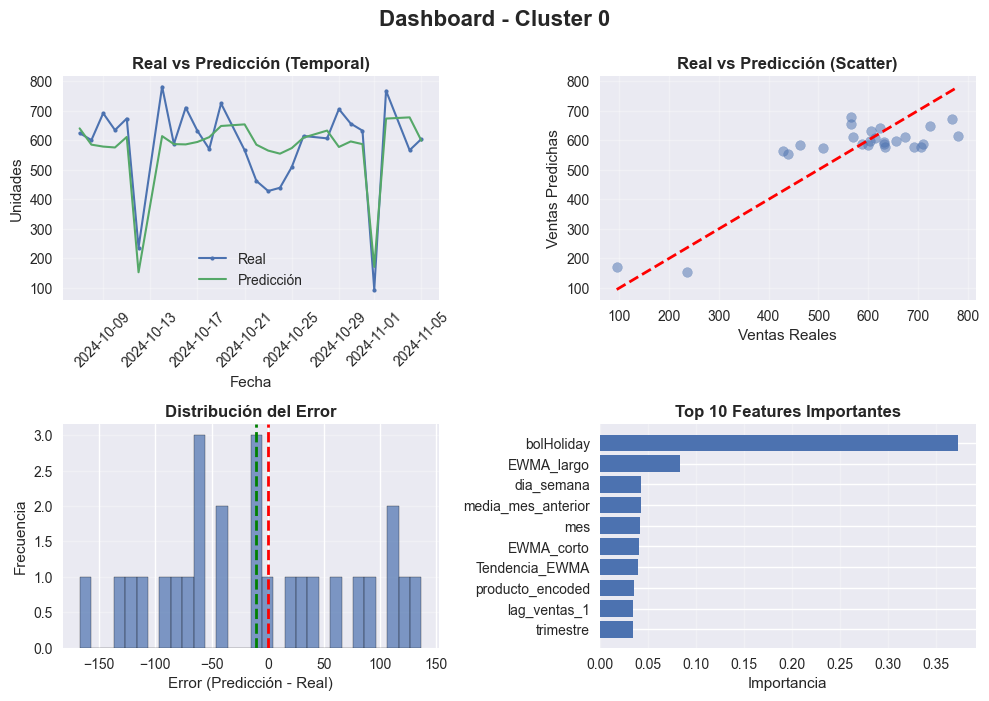


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        1     None 2.8389 3.6582 0.1099     57.28      99.58 0.7311    74.45

🏆 Mejor modelo: XGBoost (RMSE: 3.6582)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        1     None 2.8389 3.6582 0.1099     57.28      99.58 0.7311    74.45

🏆 Mejor modelo: XGBoost (RMSE: 3.6582)


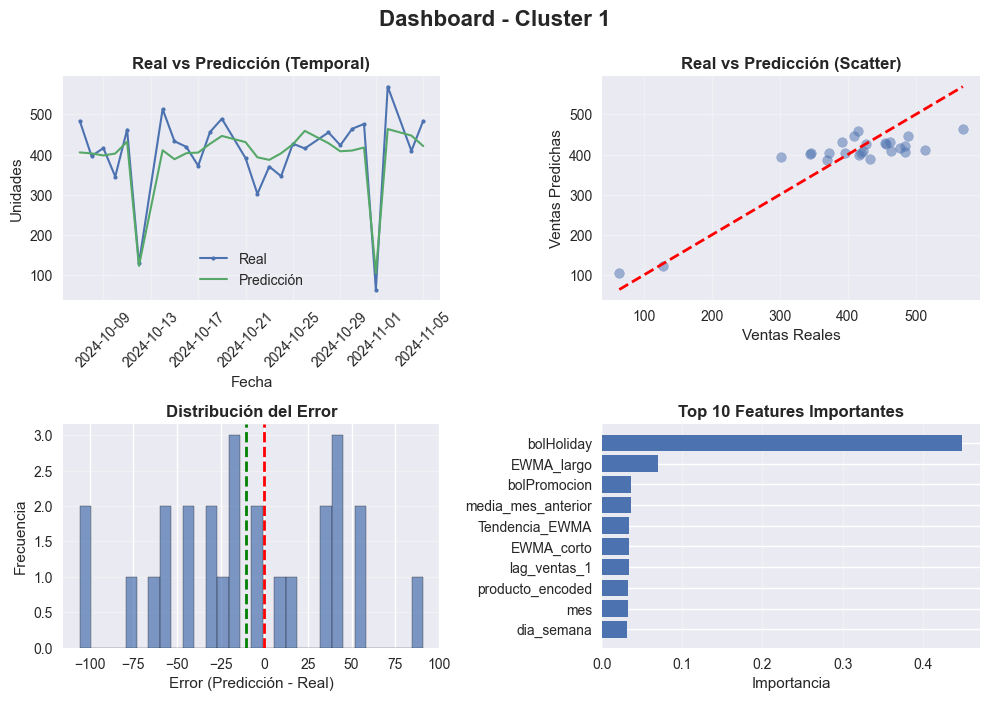


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        2     None 3.7441 5.1501 0.1804     76.87      81.84 0.7162     65.2

🏆 Mejor modelo: XGBoost (RMSE: 5.1501)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        2     None 3.7441 5.1501 0.1804     76.87      81.84 0.7162     65.2

🏆 Mejor modelo: XGBoost (RMSE: 5.1501)


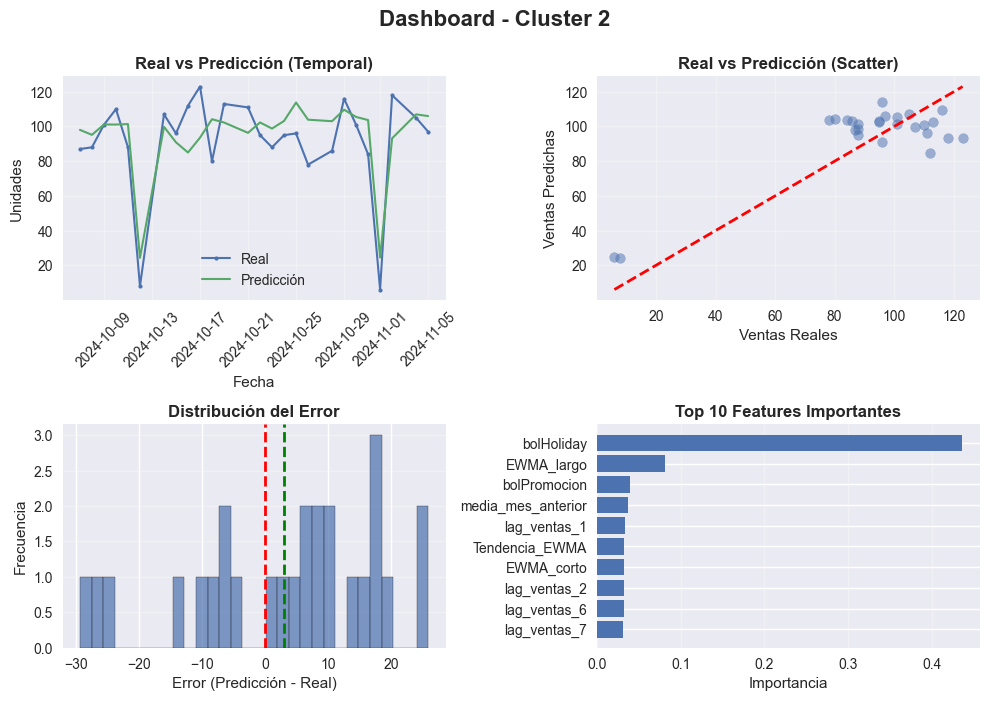


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        3     None 1.0763 1.6834 0.0505      56.1     169.32 0.7554   132.54

🏆 Mejor modelo: XGBoost (RMSE: 1.6834)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster        3     None 1.0763 1.6834 0.0505      56.1     169.32 0.7554   132.54

🏆 Mejor modelo: XGBoost (RMSE: 1.6834)


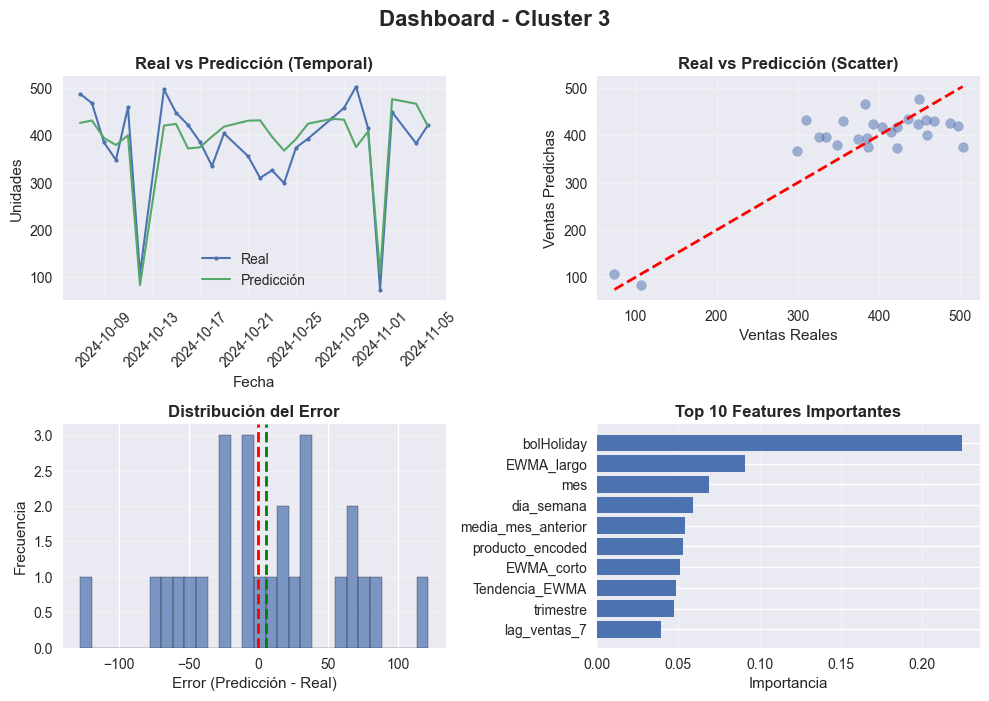

In [12]:

# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: XGBOOST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
    xgb_cluster = xgb.XGBRegressor(
        **study_xgb.best_params,
        random_state=42,
        n_jobs=-1)

    xgb_cluster.fit(X_train_c, y_train_c)
    y_pred_c = xgb_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(
        y_test_c, y_pred_c,
        algoritmo="XGBoost", ndetalle='Cluster', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)

    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='XGBoost',
            ndetalle='Cluster', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=xgb_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster}',
        figsize=(10, 7)
        )


# XGBoost por top 2 productos de ventas por cluster


📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        0       413 1.9412 2.466 -0.2564     44.92     113.38 0.8633    93.47

🏆 Mejor modelo: XGBoost (RMSE: 2.4660)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        0       413 1.9412 2.466 -0.2564     44.92     113.38 0.8633    93.47

🏆 Mejor modelo: XGBoost (RMSE: 2.4660)


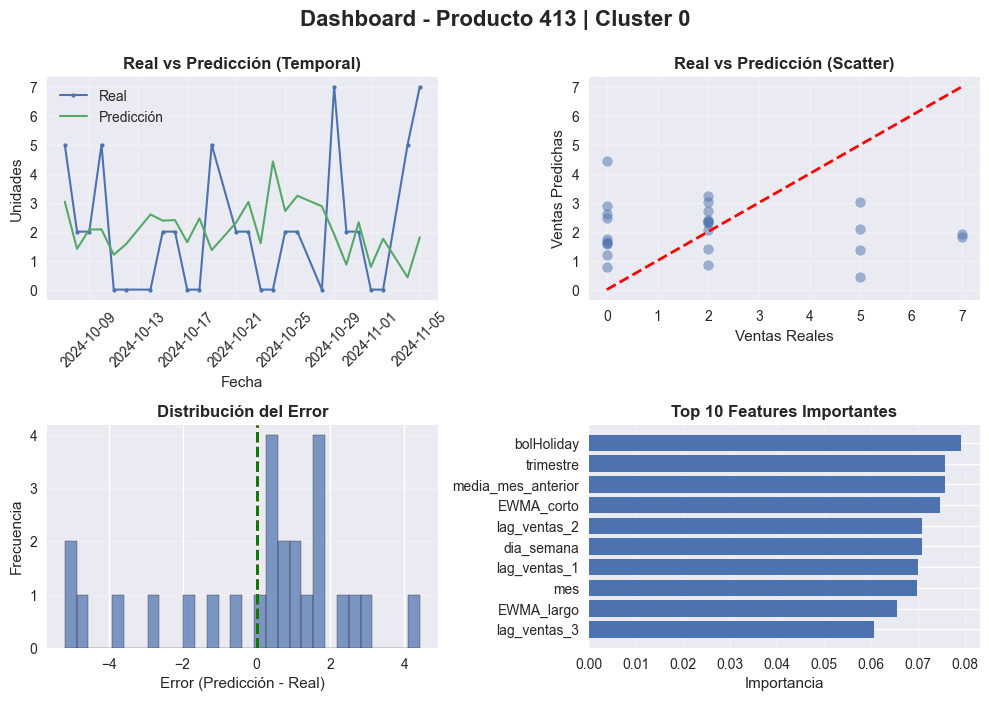


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        0       294 2.8559 3.6395 -0.6607     78.14     146.39 0.8385   154.69

🏆 Mejor modelo: XGBoost (RMSE: 3.6395)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        0       294 2.8559 3.6395 -0.6607     78.14     146.39 0.8385   154.69

🏆 Mejor modelo: XGBoost (RMSE: 3.6395)


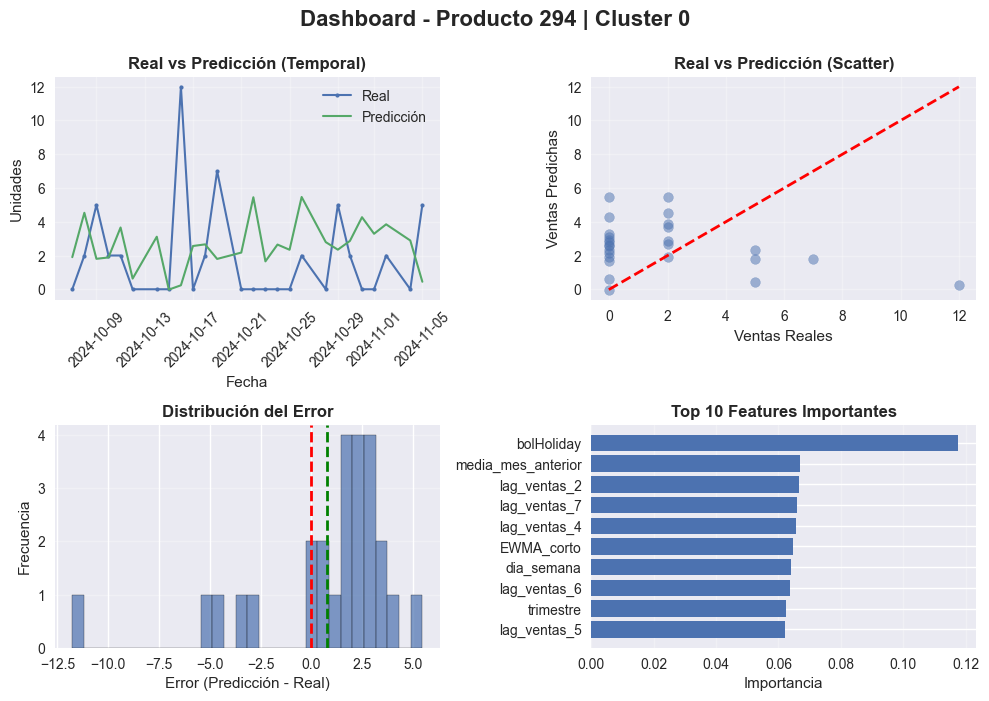


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        1       144 4.3002 5.3291 -0.1055     80.52      88.94 0.7965    76.06

🏆 Mejor modelo: XGBoost (RMSE: 5.3291)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        1       144 4.3002 5.3291 -0.1055     80.52      88.94 0.7965    76.06

🏆 Mejor modelo: XGBoost (RMSE: 5.3291)


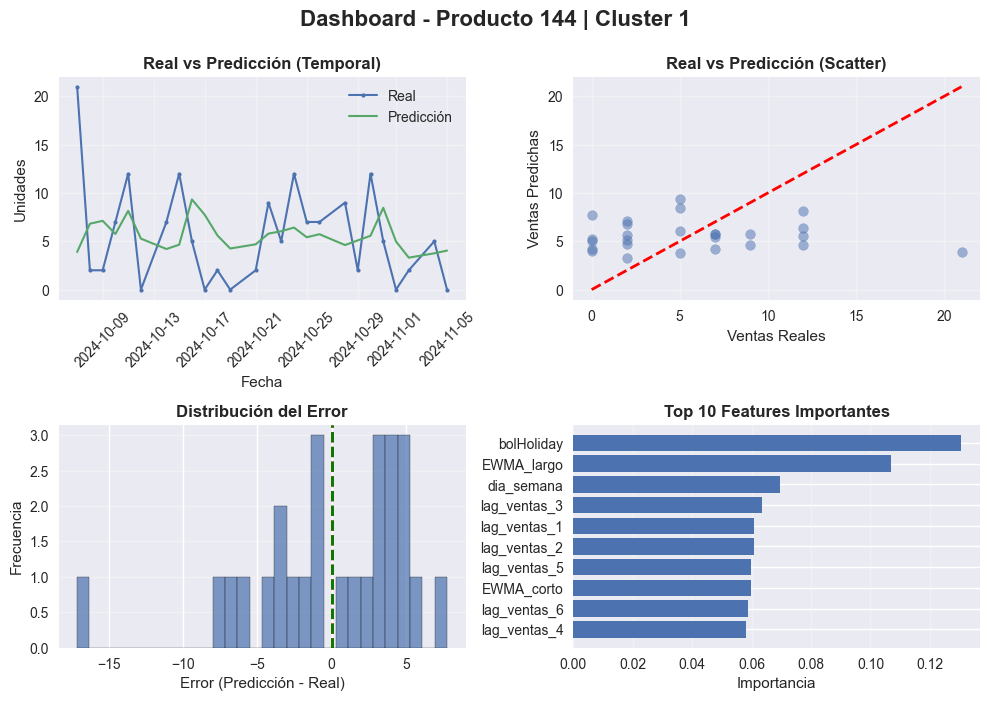


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        1        41 3.9936 5.1222 -0.2867     69.62      75.81 0.8744    60.37

🏆 Mejor modelo: XGBoost (RMSE: 5.1222)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        1        41 3.9936 5.1222 -0.2867     69.62      75.81 0.8744    60.37

🏆 Mejor modelo: XGBoost (RMSE: 5.1222)


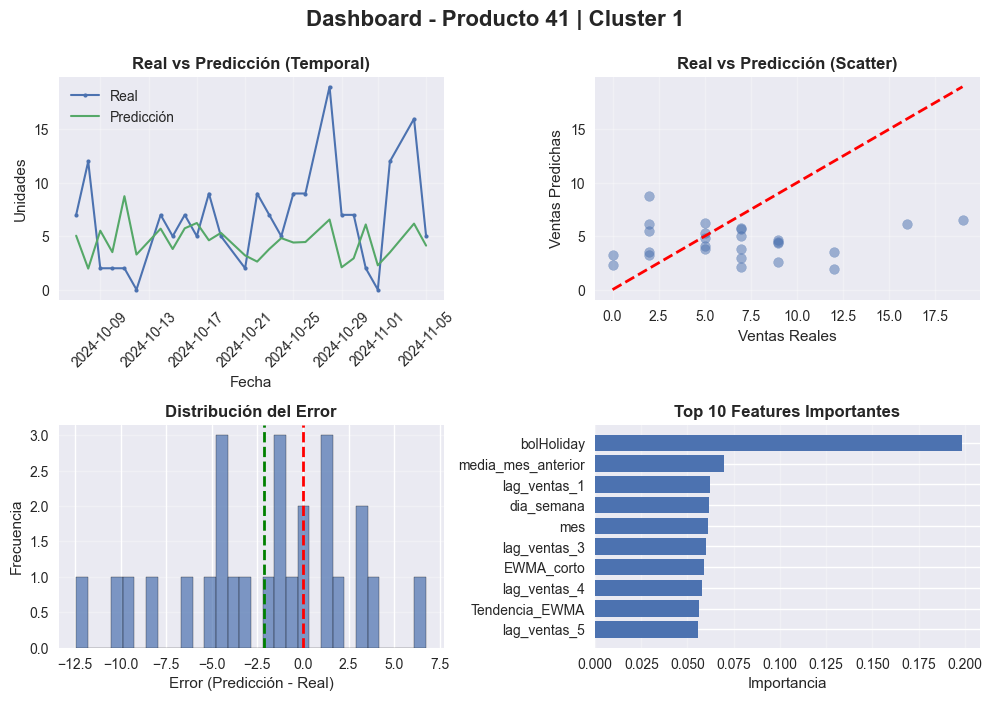


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        2         1 8.4422 11.9356 -0.1481    118.27      74.02 0.7515     71.5

🏆 Mejor modelo: XGBoost (RMSE: 11.9356)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        2         1 8.4422 11.9356 -0.1481    118.27      74.02 0.7515     71.5

🏆 Mejor modelo: XGBoost (RMSE: 11.9356)


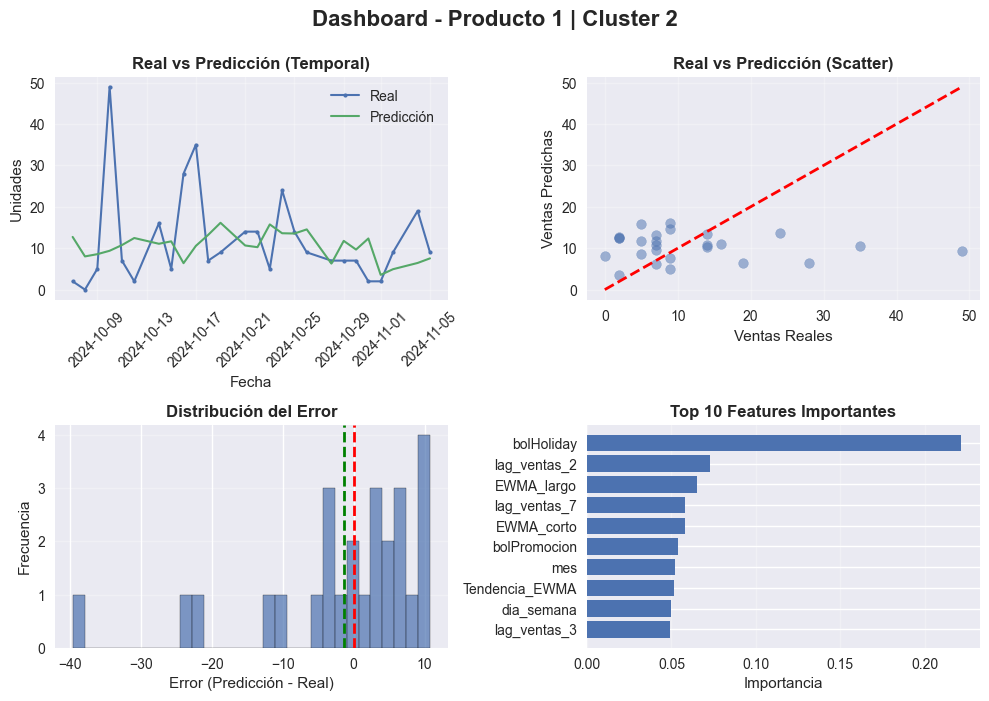


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        2         2 4.2053 5.164 -0.3044     80.03      72.29 0.7175    66.67

🏆 Mejor modelo: XGBoost (RMSE: 5.1640)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        2         2 4.2053 5.164 -0.3044     80.03      72.29 0.7175    66.67

🏆 Mejor modelo: XGBoost (RMSE: 5.1640)


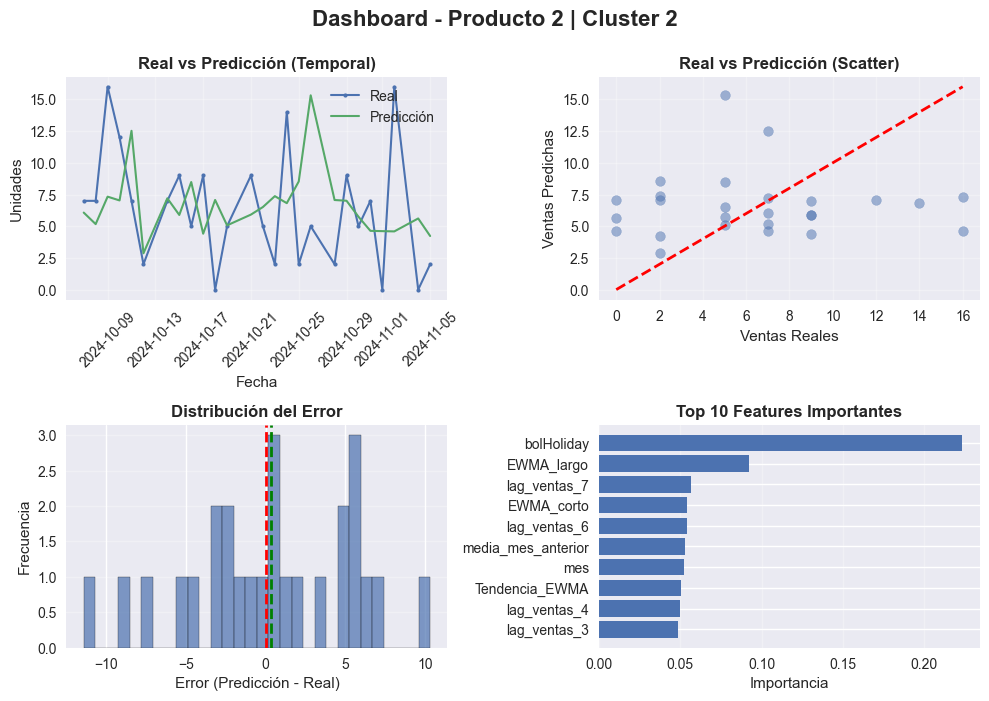


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        3       257 1.0387 1.3875 -0.4507     63.37     182.55  0.944   207.73

🏆 Mejor modelo: XGBoost (RMSE: 1.3875)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        3       257 1.0387 1.3875 -0.4507     63.37     182.55  0.944   207.73

🏆 Mejor modelo: XGBoost (RMSE: 1.3875)


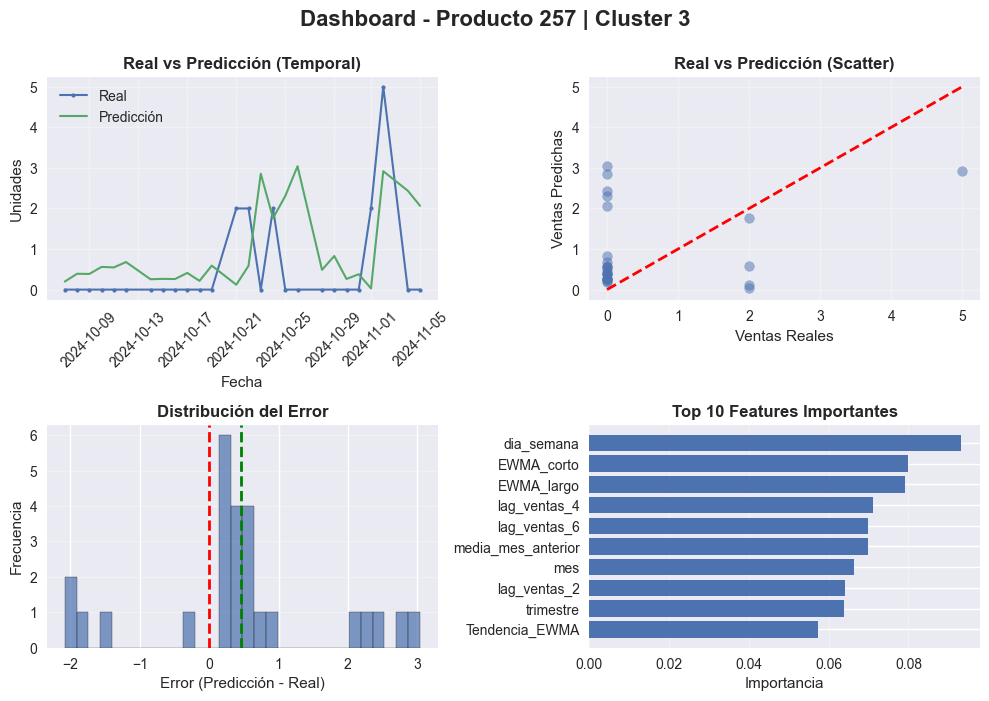


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        3       314 0.1355 0.1507 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: XGBoost (RMSE: 0.1507)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost Producto        3       314 0.1355 0.1507 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: XGBoost (RMSE: 0.1507)


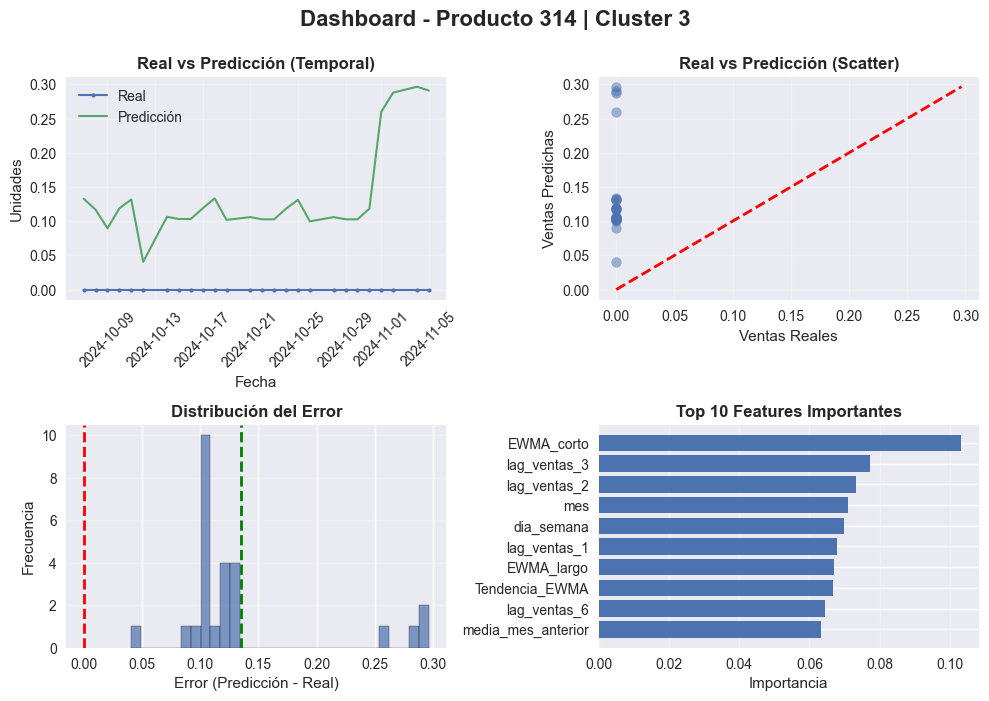


✅ Modelos por producto completados: 8 modelos entrenados


In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        xgb_cluster = xgb.XGBRegressor(
            **study_xgb.best_params,
            random_state=42,
            n_jobs=-1)
        
        xgb_cluster.fit(X_train_p, y_train_p)
        y_pred_p = xgb_cluster.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = xgb_cluster
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(
            y_test_p, y_pred_p,
            algoritmo="XGBoost",
            ndetalle='Producto', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=xgb_cluster,
            feature_names=FEATURES,
            titulo_principal=f'Dashboard - Producto {producto} | Cluster {cluster}',
            figsize=(10, 7)
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final

In [16]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

import plotly.express as px

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Tabla completa de métricas con metadatos
    print("\n📊 Resumen de todas las métricas (todas las columnas):")
    df_comparacion_final = pd.DataFrame(todas_metricas).copy()

    # Asegurar columnas y ordenar por Algoritmo y NDetalle (y RMSE ascendente dentro)
    columnas = [
        'Algoritmo', 'NDetalle', 'Cluster', 'Producto',
        'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)', 'RMSSE', 'MAE (%)'
    ]
    cols_exist = [c for c in columnas if c in df_comparacion_final.columns]

    # Reemplazar inf por NaN para ordenar correctamente
    df_comparacion_final = df_comparacion_final.replace([np.inf, -np.inf], np.nan)

    # Orden: Algoritmo, NDetalle, RMSE
    orden_cols = [c for c in ['Algoritmo', 'NDetalle', 'RMSE'] if c in df_comparacion_final.columns]
    df_comparacion_final = df_comparacion_final.sort_values(orden_cols, ascending=[True, True, True])

    print(df_comparacion_final[cols_exist].to_string(index=False))

    # Resúmenes por NDetalle
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS (NDetalle)")
    print("="*100)

    for nivel in ['Global', 'Cluster', 'Producto']:
        dfn = df_comparacion_final[df_comparacion_final['NDetalle'] == nivel]
        print(f"\n🔹 {nivel.upper()}:")
        if len(dfn) > 0:
            cols_nivel = ['Algoritmo', 'NDetalle', 'Cluster', 'Producto', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
            print(dfn[[c for c in cols_nivel if c in dfn.columns]].to_string(index=False))
            print(f"\n   Promedio RMSE: {dfn['RMSE'].mean():.2f}")
            if nivel == 'Cluster':
                print(f"   Mejor cluster: {dfn.loc[dfn['RMSE'].idxmin(), 'Cluster']} (RMSE: {dfn['RMSE'].min():.2f})")
                print(f"   Peor cluster: {dfn.loc[dfn['RMSE'].idxmax(), 'Cluster']} (RMSE: {dfn['RMSE'].max():.2f})")
            if nivel == 'Producto':
                best_idx = dfn['RMSE'].idxmin(); worst_idx = dfn['RMSE'].idxmax()
                print(f"   Mejor producto: C{dfn.loc[best_idx, 'Cluster']} P{dfn.loc[best_idx, 'Producto']} (RMSE: {dfn['RMSE'].min():.2f})")
                print(f"   Peor producto: C{dfn.loc[worst_idx, 'Cluster']} P{dfn.loc[worst_idx, 'Producto']} (RMSE: {dfn['RMSE'].max():.2f})")

    # Mejor modelo general (por RMSE)
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL (RMSE mínimo)")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]

    print(f"\n🏆 {mejor_modelo['Algoritmo']} | {mejor_modelo['NDetalle']}")
    print(f"   Cluster:    {mejor_modelo.get('Cluster', None)}")
    print(f"   Producto:   {mejor_modelo.get('Producto', None)}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   MSE:        {mejor_modelo['MSE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    print(f"   RMSSE:      {mejor_modelo['RMSSE']:.2f}")
    print(f"   MAE (%):    {mejor_modelo['MAE (%)']:.2f}")

else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if m.get('NDetalle') == 'Global'])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if m.get('NDetalle') == 'Cluster'])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if m.get('NDetalle') == 'Producto'])}")



🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  XGBoost  Cluster      3.0     314.0 0.2005   0.0583  0.2415  0.0000       NaN     200.00    NaN      NaN
  XGBoost  Cluster      3.0     257.0 0.8763   1.7651  1.3286 -0.3302     72.21     185.24 0.9040   175.25
  XGBoost  Cluster      3.0       NaN 1.0763   2.8337  1.6834  0.0505     56.10     169.32 0.7554   132.54
  XGBoost  Cluster      0.0     413.0 1.7524   4.8820  2.2095 -0.0086     36.72     104.13 0.7735    84.37
  XGBoost  Cluster      0.0       NaN 1.8058   6.7067  2.5897  0.0889     40.03     125.96 0.7445    93.52
  XGBoost  Cluster      0.0     294.0 2.2897   9.0533  3.0089 -0.1350     45.66     133.39 0.6932   124.02
  XGBoost  Cluster      1.0       NaN 2.8389  13.3823  3.6582  0.1099     57.28      99.58 0.7311    74.45
  XGBoost  Cluster      1.0      41.0

# Salvar resultados

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_xgboost.csv', index=False)